## 1. Imports and load data

In [15]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np  
import pandas as pd 
import plotly.graph_objs as go
import random
import seaborn as sns
import warnings
import urllib.parse


from scipy import stats

from flow_tree_utils import generate_trajs_from_df, load_test_df, OBJECTS, generate_flow_tree_from_trajs, plot_flow_tree

### Load articles and categories

In [3]:
### Load articles and categories
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#": continue

        # decoded_line = urllib.parse.unquote(line)
        # maybe leave in URL encoding bc the 
        article_names.append(line)

# load shortest paths


def get_nth_category(category_string, n):
    category_list = category_string.split(".")
    if len(category_list) <= n:
        return pd.NA
    return category_list[n]

# load categories
column_names = ["article", "category"]
categories_df = pd.read_csv(f"{data_path}/categories.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
categories_df["num_categories"] = categories_df["category"].apply(lambda x: len(x.split(".")))
print("Max category depth is", categories_df["num_categories"].max())
for i in range(categories_df["num_categories"].max()):
    categories_df[f"category{i}"] = categories_df["category"].apply(lambda x: get_nth_category(x, i))
categories_df


Max category depth is 4


,article,category,num_categories,category0,category1,category2,category3
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.History.British_History.British_Histor...,4,subject,History,British_History,British_History_1500_and_before_including_Roma...
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.People.Historical_figures,3,subject,People,Historical_figures,<NA>
2,%C3%85land,subject.Countries,2,subject,Countries,<NA>,<NA>
3,%C3%85land,subject.Geography.European_Geography.European_...,4,subject,Geography,European_Geography,European_Countries
4,%C3%89douard_Manet,subject.People.Artists,3,subject,People,Artists,<NA>
...,...,...,...,...,...,...,...
5199,Zirconium,subject.Science.Chemistry.Chemical_elements,4,subject,Science,Chemistry,Chemical_elements
5200,Zoroaster,subject.People.Religious_figures_and_leaders,3,subject,People,Religious_figures_and_leaders,<NA>
5201,Zuid-Gelders,subject.Geography.European_Geography,3,subject,Geography,European_Geography,<NA>
5202,Zuid-Gelders,subject.Language_and_literature.Languages,3,subject,Language_and_literature,Languages,<NA>


### Load edges

In [4]:
# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(f"{data_path}/links.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
edge_dict = dict(zip(edges_df.linkSource, edges_df.linkTarget))

In [5]:
max_category_depth = categories_df["num_categories"].max()

category_level_dict = {}
for i in range(max_category_depth):
    for cat in categories_df[f"category{i}"].dropna():
        category_level_dict[cat] = i

for _, row in categories_df.iterrows():
    category_level_dict[row["article"]] = row["num_categories"]

edge_level_dict = {}
for k, v in edge_dict.items():
    if k not in category_level_dict or v not in category_level_dict:
        continue
    edge_level_dict[(k, v)] = category_level_dict[v] - category_level_dict[k]

In [107]:
wikiG = nx.Graph()
wikiG.add_edges_from(zip(edges_df.linkSource, edges_df.linkTarget))

closeness_centrality = nx.closeness_centrality(wikiG)
print("closeness_centrality:", closeness_centrality)

closeness_centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.35405420543299, 'Columba': 0.3627088015471261, 'D%C3%A1l_Riata': 0.3632260128620154, 'Great_Britain': 0.47151398193718846, 'Ireland': 0.490374541214676, 'Isle_of_Man': 0.4503488812844731, 'Monarchy': 0.45992596653197115, 'Orkney': 0.42160937566503176, 'Picts': 0.3877708017893454, 'Scotland': 0.49712696089745423, 'Wales': 0.4542754344949193, '%C3%85land': 0.39793455653161086, '20th_century': 0.5040679375942414, 'Baltic_Sea': 0.4565825493285422, 'Crimean_War': 0.40813619016888203, 'Currency': 0.48375205321346487, 'Euro': 0.4545005908363621, 'European_Union': 0.4941267335227094, 'Finland': 0.4766114303905635, 'League_of_Nations': 0.4710779780496476, 'List_of_countries_by_system_of_government': 0.47552395357365906, 'Nationality': 0.41515772911601057, 'Parliamentary_system': 0.44653310872197316, 'Police': 0.45749370987399923, 'Russia': 0.5150530173396114, 'Stockholm': 0.40985089482052567, 'Sweden': 0.49815318995623864, 'Time_zone'

In [109]:
degree_centrality = nx.degree_centrality(wikiG)
print("Degree Centrality:", degree_centrality)

Degree Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.0021781746896101066, 'Columba': 0.004356349379220213, 'D%C3%A1l_Riata': 0.00631670659986931, 'Great_Britain': 0.044216946199085165, 'Ireland': 0.07841428882596385, 'Isle_of_Man': 0.018296667392724897, 'Monarchy': 0.03811805706817687, 'Orkney': 0.011762143323894577, 'Picts': 0.008277063820518406, 'Scotland': 0.08582008277063821, 'Wales': 0.042474406447397084, '%C3%85land': 0.004138531910259203, '20th_century': 0.07993901110869092, 'Baltic_Sea': 0.019385754737529952, 'Crimean_War': 0.010890873448050535, 'Currency': 0.06512742321934219, 'Euro': 0.023524286647789154, 'European_Union': 0.06643432803310825, 'Finland': 0.044434763668046176, 'League_of_Nations': 0.026355913744282294, 'List_of_countries_by_system_of_government': 0.05532563711609671, 'Nationality': 0.008494881289479417, 'Parliamentary_system': 0.023306469178828143, 'Police': 0.020474842082335003, 'Russia': 0.12175996514920497, 'Stockholm': 0.012415595730777608, 'Sweden': 

In [110]:
betweenness_centrality = nx.betweenness_centrality(wikiG)
print("Betweenness Centrality:", betweenness_centrality)

Betweenness Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 1.03123610335521e-06, 'Columba': 1.1521624788950728e-05, 'D%C3%A1l_Riata': 2.701782286931437e-05, 'Great_Britain': 0.0024108010081786988, 'Ireland': 0.0062183865831273695, 'Isle_of_Man': 0.0007160953771534171, 'Monarchy': 0.0008933079939856048, 'Orkney': 0.00020352802949341617, 'Picts': 6.809073244557776e-05, 'Scotland': 0.008528776918351855, 'Wales': 0.0021502283196126793, '%C3%85land': 3.878859113811596e-06, '20th_century': 0.008723574027976667, 'Baltic_Sea': 0.00045325252414481844, 'Crimean_War': 5.492490946236284e-05, 'Currency': 0.0014693849023757546, 'Euro': 0.00042682939492639317, 'European_Union': 0.002810915152991164, 'Finland': 0.0017925768550427288, 'League_of_Nations': 0.0003394163545402161, 'List_of_countries_by_system_of_government': 0.0006451094814095449, 'Nationality': 6.717461141644837e-05, 'Parliamentary_system': 0.00025274322752604243, 'Police': 0.00040304628839891516, 'Russia': 0.012781666777742085, 'Stock

### Load trajectories

In [6]:
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]

def get_path_len(x):
    return len(x.split(";"))

def get_least_common_level(art1, art2):
    art1_row = categories_df[categories_df["article"]==art1]
    art2_row = categories_df[categories_df["article"]==art2]

    if len(art1_row) == 0 or len(art2_row) == 0: return None
    
    lcl = None
    for i in range(max_category_depth):
        art1_cat = art1_row[f"category{i}"].iloc[0]
        art2_cat = art2_row[f"category{i}"].iloc[0] # sometimes there are two categories got to fix

        if pd.isna(art1_cat) or pd.isna(art2_cat) or art1_cat != art2_cat:
            return lcl
        else:
            lcl = i
    return lcl

    # for i in range([f"category{i}"]
def get_levels_traj(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(category_level_dict.get(articles[j], None))
                    break
        else:
            traj.append(category_level_dict.get(article, None))
    return traj

def get_level_hops(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(articles[j])
                    break
        else:
            traj.append(article)

    lcls = []
    for i in range(len(traj)-1):
        a, b = traj[i], traj[i+1]
        lcls.append(get_least_common_level(a, b))
    return lcls


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(f"{data_path}/paths_finished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(16)])
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, -1))
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "target", "type"]
unfinished_trajs_df = pd.read_csv(f"{data_path}/paths_unfinished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(17)])
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)


trajs_df


,hashedIpAddress,timestamp,durationInSec,path,rating,StartAt,EndAt,finished,target,type,traj_len,levels_traj,level_hops
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN,14th_century,African_slave_trade,True,NaN,NaN,9,"[3, 3, 3, 3, 3, 3, 3, 4, 3]","[2, 2, 0, 2, 1, 2, 0, 1]"
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0,14th_century,African_slave_trade,True,NaN,NaN,5,"[3, 3, 3, 4, 3]","[0, 1, 0, 1]"
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN,14th_century,African_slave_trade,True,NaN,NaN,8,"[3, 2, 2, 3, 3, 3, 4, 3]","[0, 3, 0, 0, 0, 0, 1]"
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN,14th_century,Greece,True,NaN,NaN,4,"[3, 3, 3, 4]","[2, 1, 0]"
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0,14th_century,John_F._Kennedy,True,NaN,NaN,7,"[3, 4, 3, 4, 3, 3, 3]","[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24870,109ed71f571d86e9,1389787605,180,Franz_Kafka;Tuberculosis;World_Health_Organiza...,NaN,Franz_Kafka,Cholera,False,Cholera,restart,8,"[3, 4, 3, 4, 2, 2, 3, 2]","[0, 0, 0, 0, 3, 1, 2]"
24871,232f992e57d43e8d,1389787697,6,Modern_history,NaN,Modern_history,Hollandic,False,Hollandic,restart,1,[3],[]
24872,2e09a7224600a7cd,1389798400,1900,Computer_programming;Linguistics;Culture;Popul...,NaN,Computer_programming,The_Beatles,False,The_Beatles,timeout,5,"[3, 3, 3, 3, 3]","[0, 0, 0, 2]"
24873,60af9e2138051b96,1389799481,1903,Jamaica;United_Kingdom;World_War_II;Battle_of_...,NaN,Jamaica,Alan_Turing,False,Alan_Turing,timeout,4,"[2, 3, 4, 3]","[0, 0, 1]"


### Process trajectories

In [7]:
# nodes need to be strings apparently
article_to_index = {article: str(i) for i, article in enumerate(article_names)}
index_to_article = {str(i): article for i, article in enumerate(article_names)}

def decode_path_to_traj(path):
    traj = []
    articles = path.split(";")
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(article_to_index[articles[j]])
                    break
        else:
            traj.append(article_to_index[article])
    return traj

trajs_df["traj"] = trajs_df["path"].apply(decode_path_to_traj) 
trajs_df["StartEnd"] = trajs_df["StartAt"] + "_" + trajs_df["EndAt"]

trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "avg_rating"]]


,StartEnd,traj,avg_rating
0,14th_century_African_slave_trade,"[10, 12, 15, 3134, 377, 105, 128, 379, 143]",3.0
1,14th_century_African_slave_trade,"[10, 1433, 128, 379, 143]",3.0
2,14th_century_African_slave_trade,"[10, 2982, 2984, 694, 3755, 128, 379, 143]",3.0
3,14th_century_Greece,"[10, 3464, 241, 1793]",NaN
4,14th_century_John_F._Kennedy,"[10, 2183, 3529, 1836, 3542, 3342, 2266]",3.0
...,...,...,...
24870,Franz_Kafka_Cholera,"[1585, 4247, 4538, 2614, 3223, 3223, 3917, 1696]",NaN
24871,Modern_history_Hollandic,[2802],NaN
24872,Computer_programming_The_Beatles,"[1008, 2478, 1098, 3315, 3315]",4.0
24873,Jamaica_Alan_Turing,"[2205, 4293, 4542, 506]",NaN


## Route 1: Analyse by trajectory

### Take k=100 most common trajectories

In [8]:
# find most common tasks
k = 100
most_common_paths = trajs_df["StartEnd"].value_counts()[:k].index.tolist()

print(f"Most common task is {most_common_paths[0]} with {len(trajs_df[trajs_df['StartEnd'] == most_common_paths[0]]['traj'])} attempts.")
print(f"{k}th most common task is {most_common_paths[-1]} with {len(trajs_df[trajs_df['StartEnd'] == most_common_paths[-1]]['traj'])} attempts")

reduced_trajs_df = trajs_df[trajs_df["StartEnd"].isin(most_common_paths)].copy()

Most common task is Brain_Telephone with 2044 attempts.
100th most common task is Jesus_Microsoft with 16 attempts


### Plot some examples

In [10]:
set(reduced_trajs_df.StartEnd)

{'14th_century_Rainbow',
 'AIDS_Jesus',
 'AIDS_Tour_de_France',
 'Acceleration_Mozilla_Firefox',
 'Achilles_tendon_Ivory',
 'Achilles_tendon_Ocean',
 'Adolf_Hitler_Jesus',
 'Africa_Differential_equation',
 'Africa_England',
 'Agriculture_Sparrow',
 'Aircraft_Google',
 'Aluminium_chloride_Parrot',
 'Animal_Dog',
 'Antlion_Hip_hop_music',
 'Apple_Banana',
 'Apple_Fruit',
 'Archbishop_of_Canterbury_Vietnam',
 'Art_Mango',
 'Asteroid_Viking',
 'Automobile_Pluto',
 'Automobile_Windows_XP',
 'Bamako_Sun',
 'Batman_Albert_Einstein',
 'Batman_Banana',
 'Batman_Bible',
 'Batman_Bill_Clinton',
 'Batman_Coconut_crab',
 'Batman_Japan',
 'Batman_Peanut',
 'Batman_Penguin',
 'Batman_The_Holocaust',
 'Batman_Vitamin_D',
 'Batman_Wood',
 'Beer_Sun',
 'Bird_Adolf_Hitler',
 'Bird_Great_white_shark',
 'Bird_Thomas_Jefferson',
 'Bird_migration_Hubble_Space_Telescope',
 'Brain_Telephone',
 'Brazil_Hydrogen',
 'Brazil_Vitamin',
 'Brothers_Grimm_Windows_Vista',
 'Calculus_Lemon',
 'Calculus_Paul_McCartney',


In [11]:
# compatibility
test_df = reduced_trajs_df

In [13]:
test_df.columns

Index(['hashedIpAddress', 'timestamp', 'durationInSec', 'path', 'rating',
       'StartAt', 'EndAt', 'finished', 'target', 'type', 'traj_len',
       'levels_traj', 'level_hops', 'traj', 'StartEnd', 'avg_rating'],
      dtype='object')

56
[('347', '3473135'), ('347', '3472025192216022635'), ('347', '3477223136'), ('347', '3474330377328174683261246512813804684424194044371553419730516022635'), ('347', '3479693425393932393261192216022635'), ('347', '34727612170276212834884553790379020982874287423562356117111718743621'), ('347', '34715093135'), ('347', '347894894202514916022635'), ('347', '3471433382938293829'), ('347', '3472780256320254010122144622774271215483674367414721174245533612271692138569415501463454136273114373024462007347347202520259442120207042025881294838310959034681879194045043281343722323793925154815486841282161216134263933268336533283261368016022635'), ('347', '3472552553650586326141972635'), ('3473135', '34731352933'), ('3473135', '347313531353135313527809075725725721733'), ('3473135', '34731352554297'), ('34731352933', '347313529333261419730516022635'), ('34731352933', '347313529333261368016022635')]
36
[('894', '8941820'), ('894', '89442972832'), ('894', '89420084293'), ('894', '894278217862832'), ('894

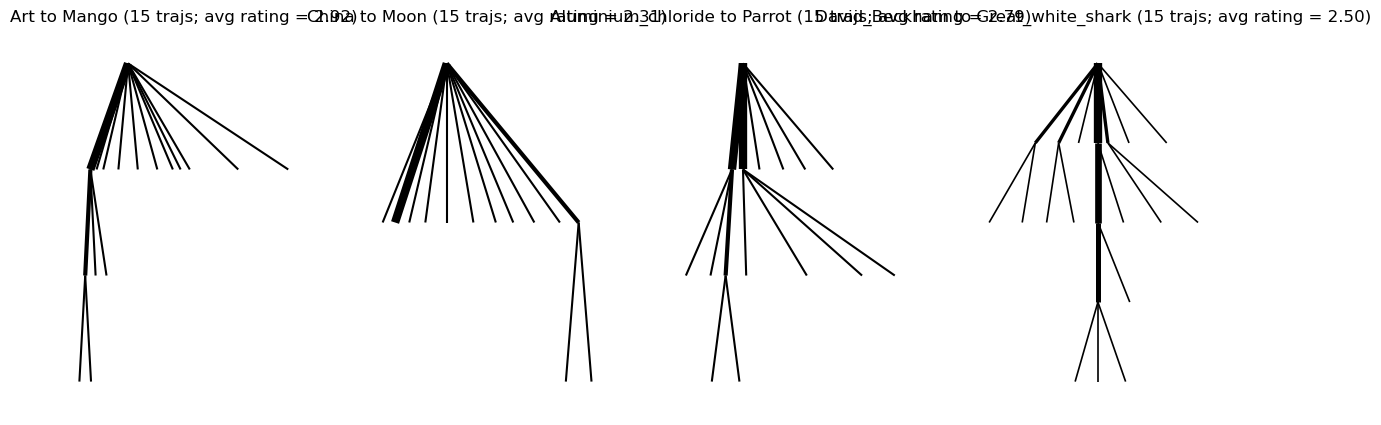

Art-Mango 2.92


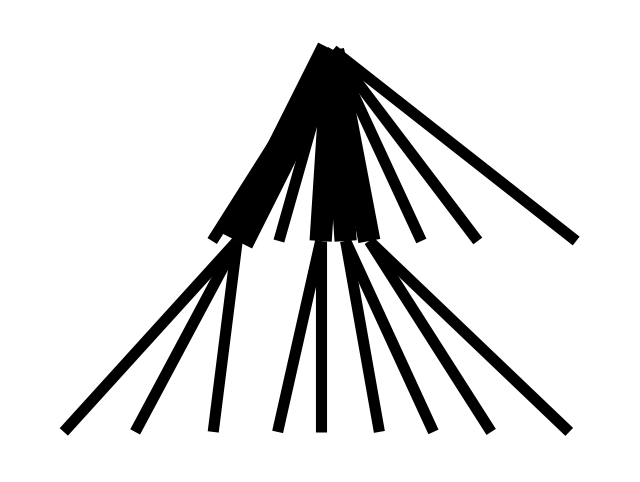

China-Moon 2.31


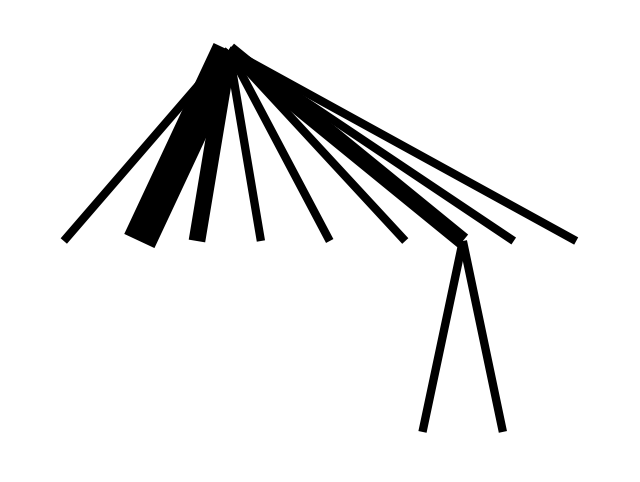

Aluminium_chloride-Parrot 2.79


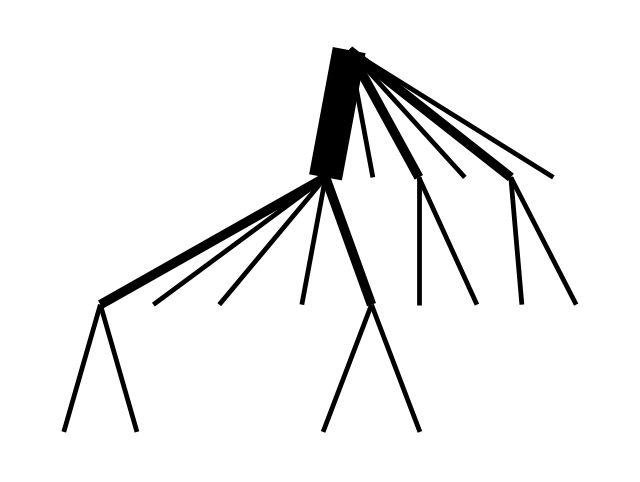

David_Beckham-Great_white_shark 2.50


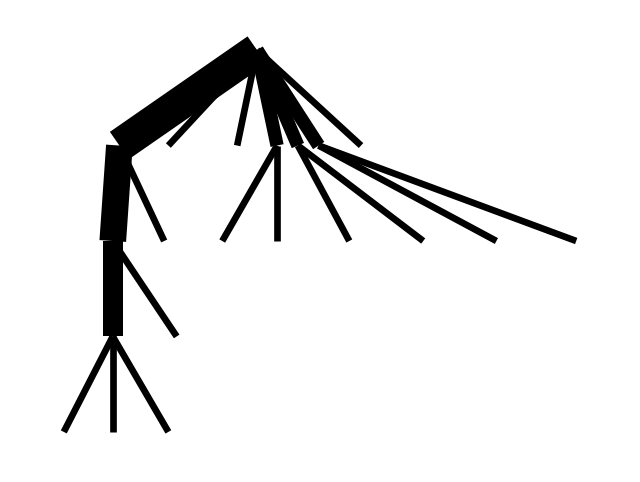

In [24]:
##############################
## Four Examples (prettier) ##
##############################
paths_to_plot = [("Art", "Mango"), ("China", "Moon"), ("Aluminium_chloride", "Parrot"), ("David_Beckham", "Great_white_shark")]

fig, axes = plt.subplots(1, len(paths_to_plot), figsize=(15,5))
for i, (start_node, end_node) in enumerate(paths_to_plot):
    this_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]# & test_df["accuracy"]]
    
    avg_rating = this_df["avg_rating"].iloc[0]
    print(len(this_df["traj"]))
    trajs = random.sample([x for x in this_df["traj"]], min(15, len(this_df["traj"]))) #random.sample(generate_trajs_from_df(this_df), min(67, len(generate_trajs_from_df(this_df))))
    G = generate_flow_tree_from_trajs(trajs)
    G.remove_edges_from(nx.selfloop_edges(G))
    print(G.edges)
    plot_flow_tree(G, f"{start_node} to {end_node} ({len(trajs)} trajs; avg rating = {avg_rating:.2f})", axes[i], just_edges=True)
    
plt.show()

for i, (start_node, end_node) in enumerate(paths_to_plot):
    this_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]# & test_df["accuracy"]]

    avg_rating = this_df["avg_rating"].iloc[0]
    trajs = random.sample([x for x in this_df["traj"]], min(15, len(this_df["traj"]))) #random.sample(generate_trajs_from_df(this_df), min(67, len(generate_trajs_from_df(this_df))))
    G = generate_flow_tree_from_trajs(trajs)
    G.remove_edges_from(nx.selfloop_edges(G))

    print(f"{start_node}-{end_node} {avg_rating:.2f}")
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_flow_tree(G, "", ax, just_edges=True, edge_boldness=4)
    plt.show()

## Now regression

In [73]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    print(max_weight)
    backbone_thickness = np.mean(weights) / max_weight
    print(backbone_thickness)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
    
    return features

def extract_static_features(df):
    # euclid_distance = df["Euc.Distance"].mode().iloc[0]
    # path_distance = df["Path.Distance"].mode().iloc[0]
    # num_nodes = df["Num.Nodes"].mode().iloc[0]
    
    avg_duration = df["durationInSec"].mean()
    # avg_path_dist_traveled = df["path_dist_trav"].mean()
    avg_traj_len = df["traj_len"].mean()
    # avg_turns_count = df["turns_count"].mean()

    return [avg_duration, avg_traj_len]



In [ ]:
# hashedIpAddress', 'timestamp', 'durationInSec', 'path', 'rating',
#        'StartAt', 'EndAt', 'finished', 'target', 'type', 'traj_len',
#        'levels_traj', 'level_hops', 'traj', 'StartEnd', 'avg_rating

In [33]:
test_df["accuracy"] = test_df["finished"]
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

In [32]:
# potential regressors
# avg_rating
# path_mean_acc

In [116]:
only_winners = True
only_losers = False

static_features = []
flow_tree_features = []
flow_trees = []
accuracies = []
ratings = []

if only_losers:
    min_sample_size = test_df[~test_df["accuracy"]].groupby(["StartAt", "EndAt"]).count().min()[0]
elif only_winners:
    min_sample_size = test_df[test_df["accuracy"]].groupby(["StartAt", "EndAt"]).count().min()[0]
else:
    min_sample_size = test_df.groupby(["StartAt", "EndAt"]).count().min()[0]
min_sample_size = 10
print("Min sample size:", min_sample_size)

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    if only_losers: group = group[~group["accuracy"]]
    elif only_winners: group = group[group["accuracy"]]

    if len(group) == 0: continue
    
    acc = group["path_mean_acc"].iloc[0]
    rat = group["avg_rating"].iloc[0]

    # sample 5 times for each flow tree
    for i in range(5):
        
        sample_df1 = group.sample(n=min(min_sample_size, len(group)), random_state=i, replace=False) 

        trajs1 = np.array(sample_df1["traj"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=end_node)
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

        flow_trees.append(new_G1)
        accuracies.append(acc)
        ratings.append(rat)
        
        static_features.append(extract_static_features(sample_df1))
        flow_tree_features.append(extract_tree_features(new_G1, 0))

static_features = np.array(static_features)
flow_tree_features = np.array(flow_tree_features)
accuracies = np.array(accuracies)
ratings = np.array(ratings)

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_83485/1167382080.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min_sample_size = test_df[test_df["accuracy"]].groupby(["StartAt", "EndAt"]).count().min()[0]


Min sample size: 10
5
0.5
4
0.5
7
0.5
13
0.3333333333333333
8
0.5
3
0.5
4
0.5
5
0.5
3
0.5
3
0.5
4
1.0
4
1.0
4
1.0
4
1.0
4
1.0
7
0.33333333333333337
7
0.33333333333333337
4
0.5
7
0.33333333333333337
7
0.33333333333333337
13
0.3333333333333333
11
0.3333333333333333
16
0.3333333333333333
14
0.33333333333333337
13
0.3333333333333333
14
0.33333333333333337
12
0.3333333333333333
16
0.3333333333333333
15
0.3333333333333333
18
0.3333333333333333
13
0.3333333333333333
14
0.33333333333333337
15
0.3333333333333333
16
0.3333333333333333
12
0.5
3
0.5
3
0.5
1
1.0
2
1.0
2
1.0
4
0.5
5
0.5
6
0.3333333333333333
6
0.3333333333333333
2
1.0
6
0.3333333333333333
6
0.3333333333333333
6
0.3333333333333333
4
1.0
4
1.0
12
0.25
4
0.5
3
0.5
16
0.25
9
0.3333333333333333
6
0.3333333333333333
4
0.5
4
0.5
5
0.5
3
0.5
2
1.0
2
1.0
2
1.0
2
1.0
2
1.0
7
0.5
13
0.3333333333333333
10
0.33333333333333337
7
0.5
6
0.3333333333333333
10
1.0
10
1.0
10
1.0
10
1.0
10
1.0
10
1.0
10
1.0
10
1.0
10
1.0
10
1.0
8
0.5
4
0.5
5
0.5
8
0.5
5

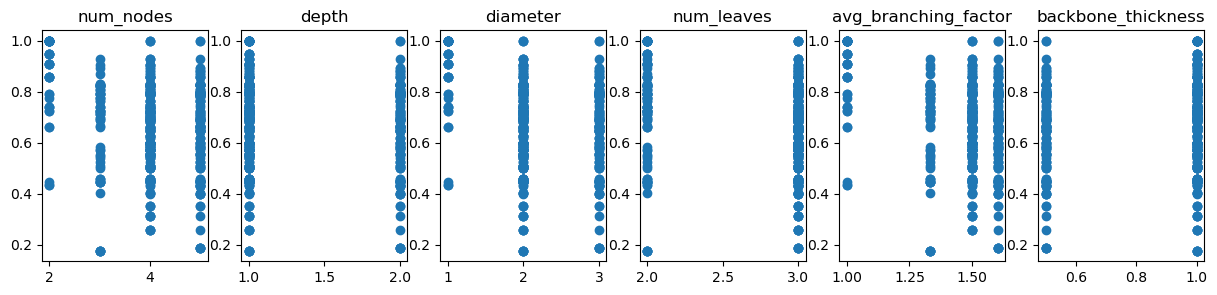

In [78]:
# plot lines of all features
feats = [
        "num_nodes",
        "depth",
        "diameter",
        "num_leaves",
        "avg_branching_factor",
        "backbone_thickness"
    ]

fig, axes = plt.subplots(1, flow_tree_features.shape[1], figsize=(15,3))
for i in range(flow_tree_features.shape[1]):
    axes[i].scatter(flow_tree_features[:, i], accuracies)
    axes[i].set_title(feats[i])


In [95]:
import karateclub as kc
from sklearn.decomposition import PCA

# Compute embeddings
flow_tree_embedder = kc.Graph2Vec(dimensions=64)
flow_tree_embedder.fit(flow_trees)

flow_tree_embeddings = flow_tree_embedder.infer(flow_trees)

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(flow_tree_embeddings)

# print(reduced_features)

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/karateclub/estimator.py:63: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(


## Run regression

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, norm
import matplotlib.gridspec as gridspec


def run_evaluate_regression(X, y, feature_str="", axes=["", "", ""], y_axis=False):
    # Initialize and fit the linear regression model
    model = LinearRegression()
    
    ## K-fold cross validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store RMSE for each fold
    rmse_list = []

    slopes = []
    
    # Perform the cross-validation
    for train_index, test_index in kf.split(X):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Append RMSE to the list
        rmse_list.append(rmse)

        slopes.append(model.coef_)
    
    # Convert RMSE list to a numpy array for statistical calculations
    rmse_array = np.array(rmse_list)
    
    mean_rmse = np.mean(rmse_array)
    std_rmse = np.std(rmse_array)
    
    print(f"Mean RMSE: {mean_rmse:0.4f} $\\pm$ {std_rmse:0.5f}")
    
    # Get the regression coefficient and intercept
    slopes = np.array(slopes)
    slope = np.mean(np.abs(slopes), axis=0)
    intercept = model.intercept_
    
    # print(f"Linear Regression Coefficients:", slope)
    # print(feature_str)
    # print(f"Intercept: {intercept:.2f}")
    # print(f"R-squared: {model.score(X, y):.2f}")

    # Correlations
    # Initialize lists to store correlations and p-values
    correlations = []
    p_values = []
    
    # Loop through each feature (column) in X
    for i in range(X.shape[1]):
        corr, p_value = pearsonr(X[:, i], y)
        correlations.append(corr)
        p_values.append(p_value)
    
    # Convert to numpy array for easier manipulation
    correlations = np.array(correlations)
    p_values = np.array(p_values)

    # Identify top 3 most important features based on absolute value of coefficients
    top_features_indices = np.argsort(np.abs(slope))[-3:]  # Indices of the top 3 features
    top_features_names = np.array(feature_str.split(","))[top_features_indices]   # Names of the top 3 features
    
    # Create subplots with 3 plots (one for each top feature)
    #, subplot_titles=top_features_names)
    
    # Plot each feature against the true y values in separate subplots
    j = 0
    if len(top_features_indices) > 1:
    # else: 
    #     top_features_indices = [top_features_indices[0], top_features_indices[2], top_features_indices[1]]
        fig, axes = plt.subplots(1, 3, figsize=(5, 15))
        for i in reversed(top_features_indices):
            feature_name = np.array(feature_str.split(","))[i]

            axes[j].scatter(X[:, i], y, c="#2a2d7c")
            print(f'Feature {i} corr={correlations[i]:0.3f}, $p$={p_values[i]:0.5f}')


            feature_model = LinearRegression()
            feature_X = X[:,i:i+1] 
            feature_model.fit(feature_X, y)
            
            # Plot regression line: feature vs predicted y (y_pred)
            # Create values for the best-fit line
            feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
            feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

            axes[j].plot(feature_x_range, feature_y_pred, c="#FF5A5F")
            print(f'{slope[i]:0.2f} {feature_name} regression line')

            j+=1
    else:

        i=0
        to_plot = X[:, i]
        
        line_color, dot_color = ("#FF5A5F", "#2A2D7C") 

        fig = plt.figure(figsize=(6, 6))
        gs = gridspec.GridSpec(2, 1, height_ratios=[1, .1], hspace=0.05)

        ax = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])

        ax.scatter(to_plot, y, c=dot_color, alpha=0.5, s=100)
        print(f"n={len(to_plot)}")
        print(f'Feature {i} corr={correlations[i]:0.3f}, $p$={p_values[i]:0.5f}')

        feature_model = LinearRegression()
        feature_X = X[:,i:i+1] 
        feature_model.fit(feature_X, y)
        
        # Plot regression line
        feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
        feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

        ax.plot(feature_x_range, feature_y_pred, c=line_color, linewidth=4)

        # FOR Y AXIS
        fudge = (np.max(y) - np.min(y)) * .1
        ylim = [np.min(y) - fudge, np.max(y) + fudge]
        ax.set_ylim(*ylim)  # most of data
        ax2.set_ylim(0, .1)  # emptiness

        d = .3  # proportion of vertical to horizontal extent of the slanted line
        kwargs = dict(marker=[(-1, -d), (1, d)], markersize=30,
                    linestyle="none", color='k', mec='k', mew=2, clip_on=False)
        ax.plot([0], [0], transform=ax.transAxes, **kwargs)
        ax2.plot([0], [1], transform=ax2.transAxes, **kwargs)

        plt.yticks([0])

        # FOR X AXIS -- Normalised already alhamdulilah
        ax2.set_xlim(0, 1)  # emptiness

        for axx in [ax, ax2]:
            axx.spines["top"].set_visible(False)
            axx.spines["right"].set_visible(False)        

            axx.spines["left"].set_linewidth(2.5)
            axx.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
        
        ax.xaxis.set_visible(False)
        ax.spines["bottom"].set_visible(False)        
        ax2.spines["bottom"].set_linewidth(2.5)

        plt.margins(x=.1, y=.1)
        plt.show()

Avg duration
Mean RMSE: 0.1418 $\pm$ 0.01163
n=500
Feature 0 corr=-0.596, $p$=0.00000


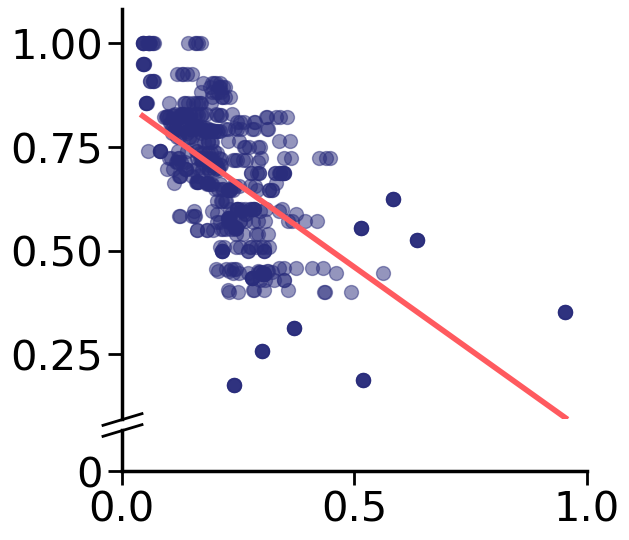

Avg traj len
Mean RMSE: 0.1456 $\pm$ 0.01032
n=500
Feature 0 corr=-0.566, $p$=0.00000


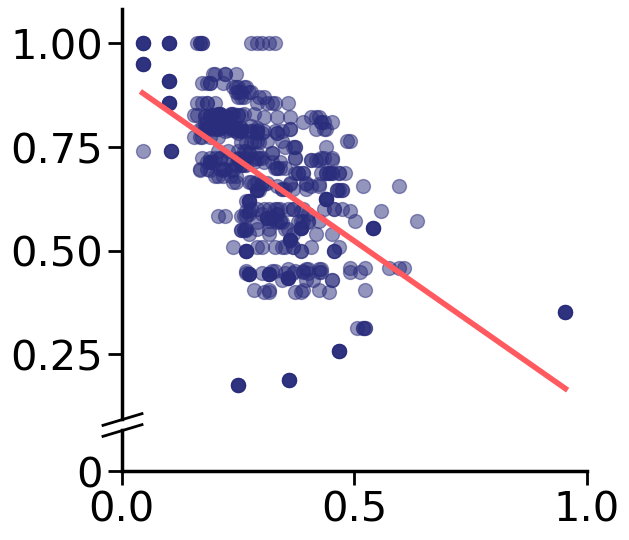

In [117]:
# feats = ["avg_duration", "avg_traj_len"]

# norm static features
normed_static_features = np.ones_like(static_features)
for i in range(static_features.shape[1]):
    normed = static_features[:,i]
    min_val, max_val = normed.min(), normed.max()
    normed = (normed - min_val) / (max_val - min_val)

    normed_static_features[:,i] = normed

print("Avg duration")
run_evaluate_regression(normed_static_features[:,0].reshape(-1, 1), accuracies, feature_str="avg_duration,avg_traj_len", axes=["", "", ""], y_axis=True)

print("Avg traj len")
run_evaluate_regression(normed_static_features[:,1].reshape(-1, 1), accuracies, feature_str="avg_duration,avg_traj_len", axes=["", "", ""])


Avg duration
Mean RMSE: 0.7129 $\pm$ 0.03316
n=495
Feature 0 corr=0.313, $p$=0.00000


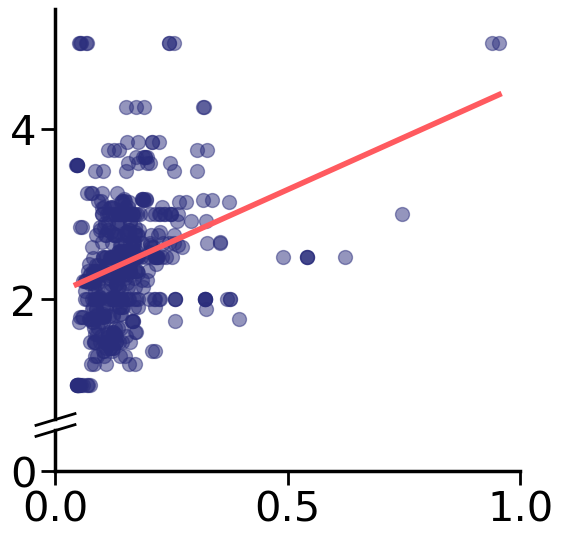

Avg traj len
Mean RMSE: 0.6899 $\pm$ 0.04569
n=495
Feature 0 corr=0.381, $p$=0.00000


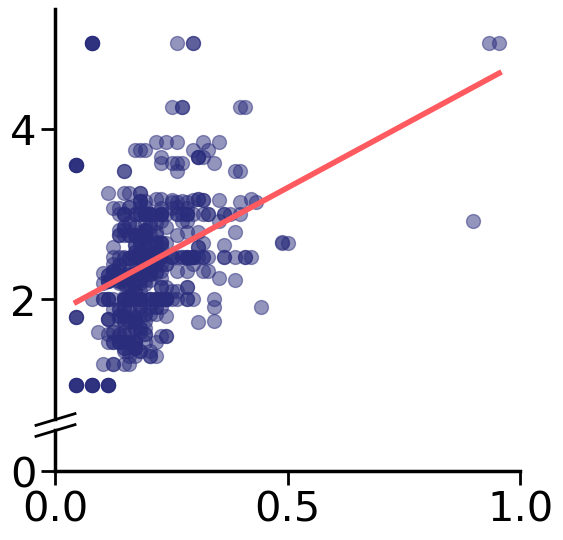

In [88]:
# feats = ["avg_duration", "avg_traj_len"]
rat_nans = np.isnan(ratings)
ratings_nona = ratings[~rat_nans]
s_feats = static_features[~rat_nans,:]


# norm static features
normed_static_features = np.ones_like(s_feats)
for i in range(s_feats.shape[1]):
    normed = s_feats[:,i]
    min_val, max_val = normed.min(), normed.max()
    normed = (normed - min_val) / (max_val - min_val)

    normed_static_features[:,i] = normed

print("Avg duration")
run_evaluate_regression(normed_static_features[:,0].reshape(-1, 1), ratings_nona, feature_str="avg_duration,avg_traj_len", axes=["", "", ""], y_axis=True)

print("Avg traj len")
run_evaluate_regression(normed_static_features[:,1].reshape(-1, 1), ratings_nona, feature_str="avg_duration,avg_traj_len", axes=["", "", ""])


num_nodes
Mean RMSE: 0.1693 $\pm$ 0.01223
n=500
Feature 0 corr=-0.292, $p$=0.00000


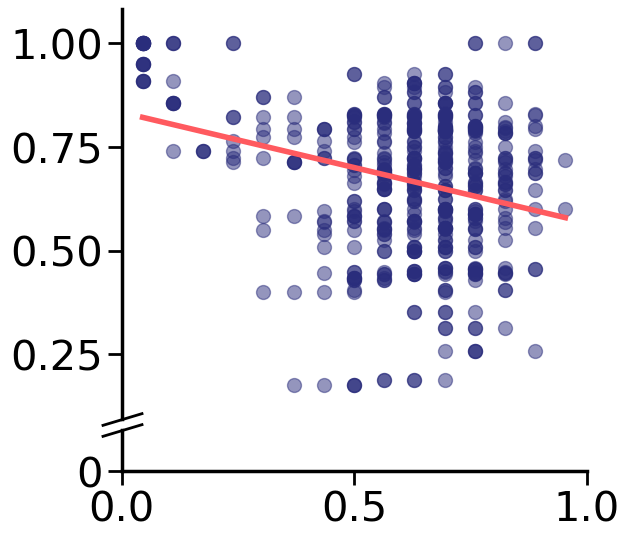

depth
Mean RMSE: 0.1773 $\pm$ 0.01056
n=500
Feature 0 corr=-0.035, $p$=0.42973


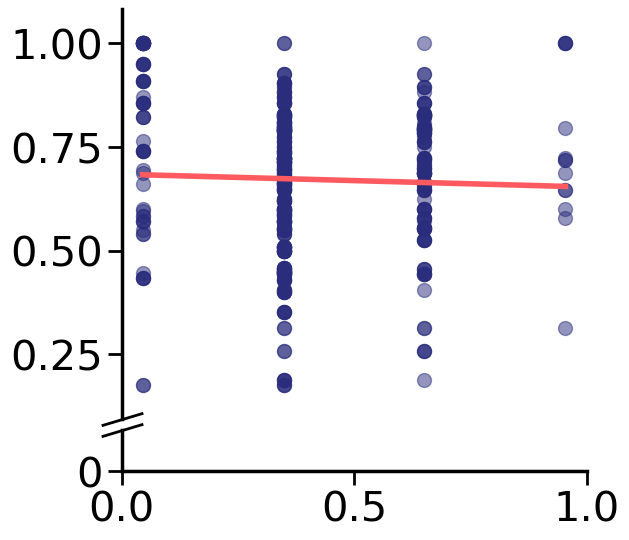

avg_branching_factor
Mean RMSE: 0.1584 $\pm$ 0.01439
n=500
Feature 0 corr=-0.435, $p$=0.00000


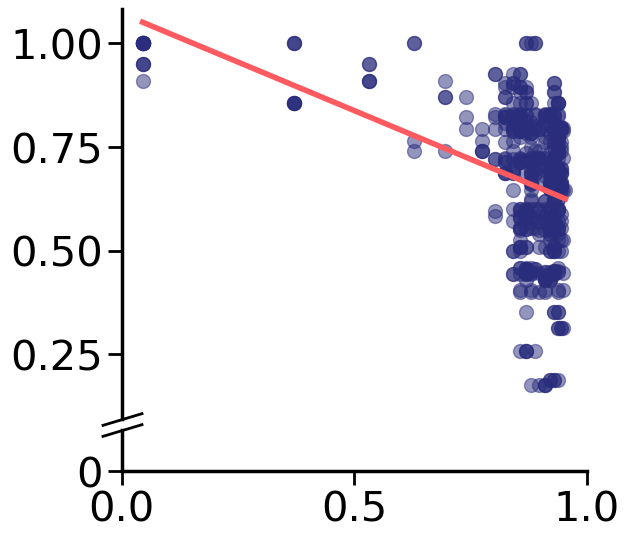

backbone_thickness
Mean RMSE: 0.1766 $\pm$ 0.01212
n=500
Feature 0 corr=0.118, $p$=0.00826


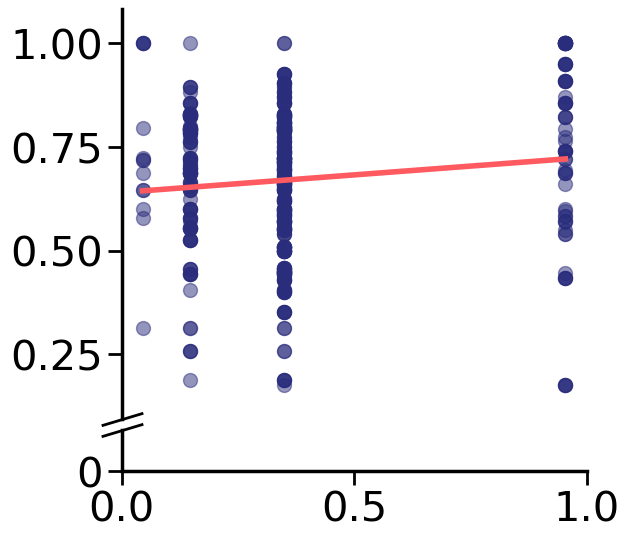

diameter
Mean RMSE: 0.1756 $\pm$ 0.01119
n=500
Feature 0 corr=-0.138, $p$=0.00199


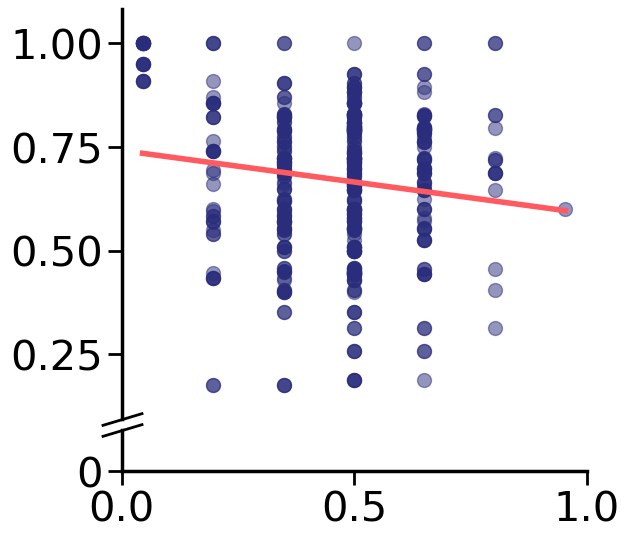

num_leaves
Mean RMSE: 0.1652 $\pm$ 0.01228
n=500
Feature 0 corr=-0.356, $p$=0.00000


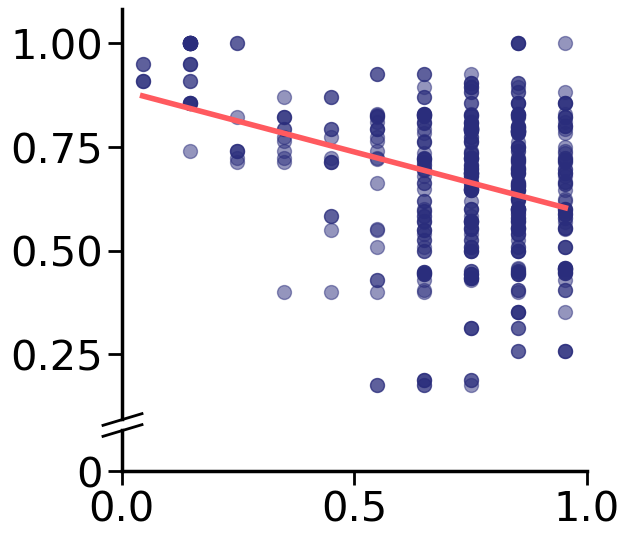

all flow tree
Mean RMSE: 0.1552 $\pm$ 0.01174
Feature 0 corr=-0.292, $p$=0.00000
0.51 num_nodes regression line
Feature 3 corr=-0.356, $p$=0.00000
0.48  num_leaves regression line
Feature 4 corr=-0.435, $p$=0.00000
0.42 avg_branching_factor regression line
embeddings
Mean RMSE: 0.1718 $\pm$ 0.01339
n=500
Feature 0 corr=-0.242, $p$=0.00000


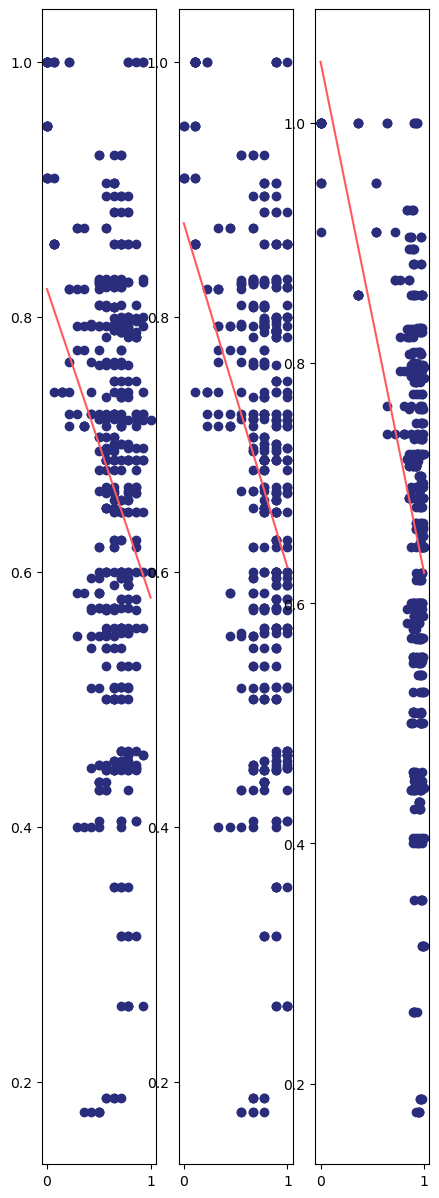

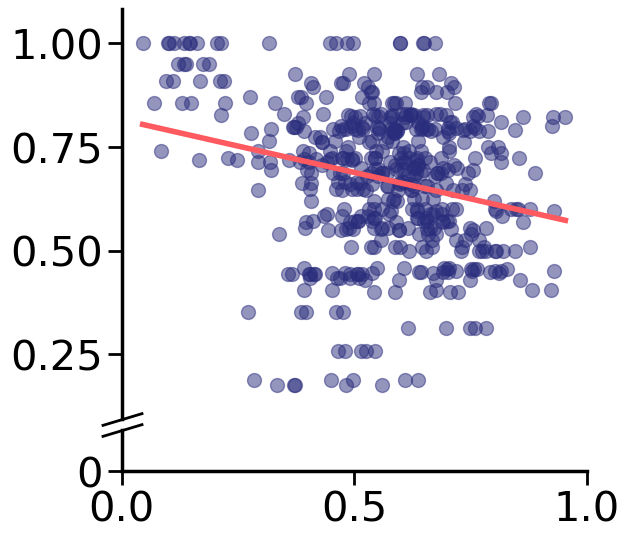

Mean RMSE: 0.1746 $\pm$ 0.01153
n=500
Feature 0 corr=-0.172, $p$=0.00011


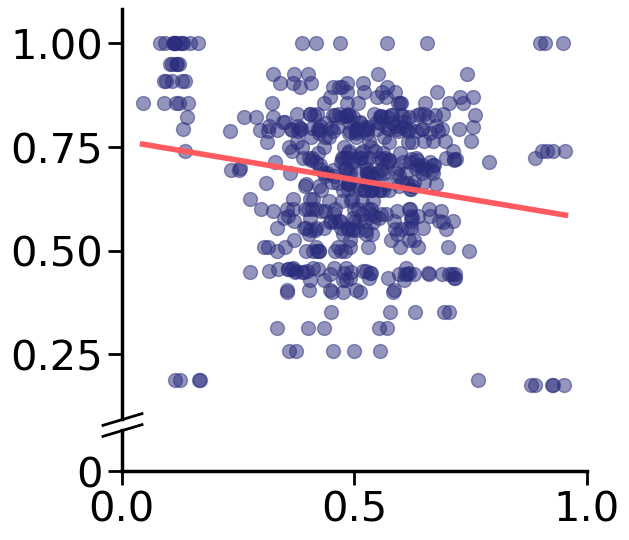

In [114]:
# norm features
normed_flow_tree_features = np.ones_like(flow_tree_features)
for i in range(flow_tree_features.shape[1]):
    normed = flow_tree_features[:,i]
    min_val, max_val = normed.min(), normed.max()
    normed = (normed - min_val) / (max_val - min_val)

    normed_flow_tree_features[:,i] = normed
    
# Flow Tree
print("num_nodes")
run_evaluate_regression(normed_flow_tree_features[:,0].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""], y_axis=True)

print("depth")
run_evaluate_regression(flow_tree_features[:,1].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("avg_branching_factor")
run_evaluate_regression(flow_tree_features[:,-2].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("backbone_thickness")
run_evaluate_regression(flow_tree_features[:,-1].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("diameter")
run_evaluate_regression(flow_tree_features[:,2].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("num_leaves")
run_evaluate_regression(flow_tree_features[:,3].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("all flow tree")
run_evaluate_regression(normed_flow_tree_features, accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])


print("embeddings")
run_evaluate_regression(reduced_features[:,0].reshape(-1, 1), accuracies, feature_str="pca1,pca2", axes=["", "", ""])
run_evaluate_regression(reduced_features[:,-1].reshape(-1, 1), accuracies, feature_str="pca1,pca2", axes=["", "", ""])

num_nodes
Mean RMSE: 0.7451 $\pm$ 0.06674
n=495
Feature 0 corr=0.109, $p$=0.01508


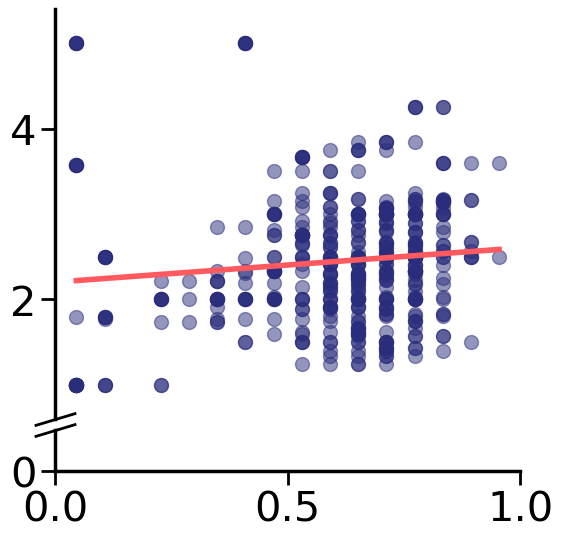

depth
Mean RMSE: 0.7446 $\pm$ 0.06264
n=495
Feature 0 corr=0.109, $p$=0.01485


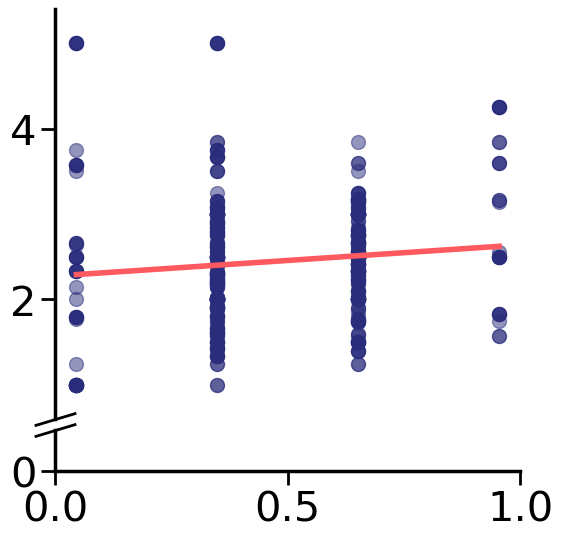

avg_branching_factor
Mean RMSE: 0.7592 $\pm$ 0.06301
n=495
Feature 0 corr=0.046, $p$=0.31108


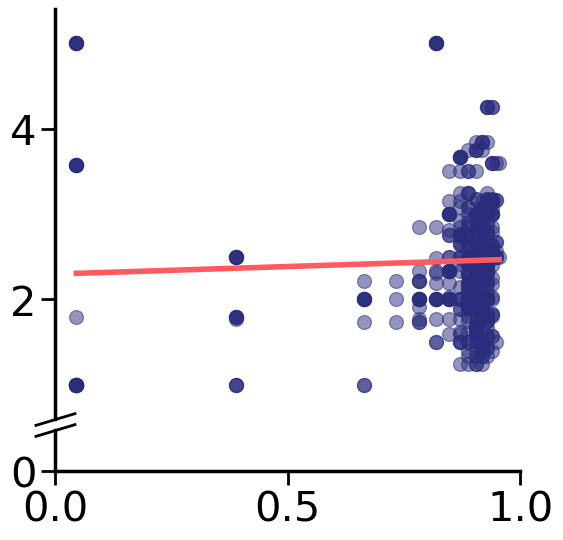

backbone_thickness
Mean RMSE: 0.7468 $\pm$ 0.06155
n=495
Feature 0 corr=-0.077, $p$=0.08540


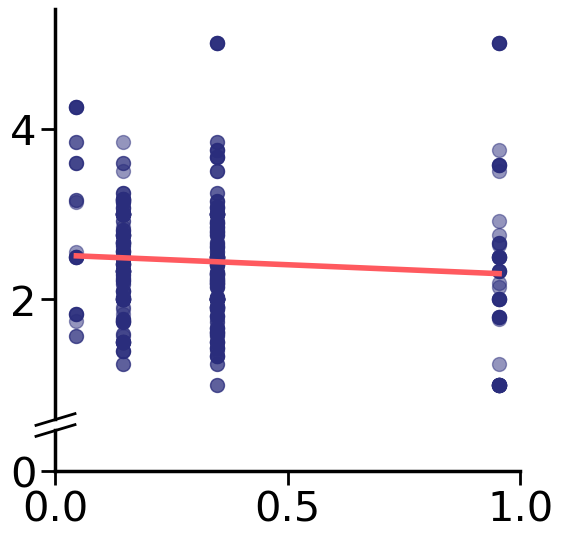

diameter
Mean RMSE: 0.7500 $\pm$ 0.06453
n=495
Feature 0 corr=0.079, $p$=0.07971


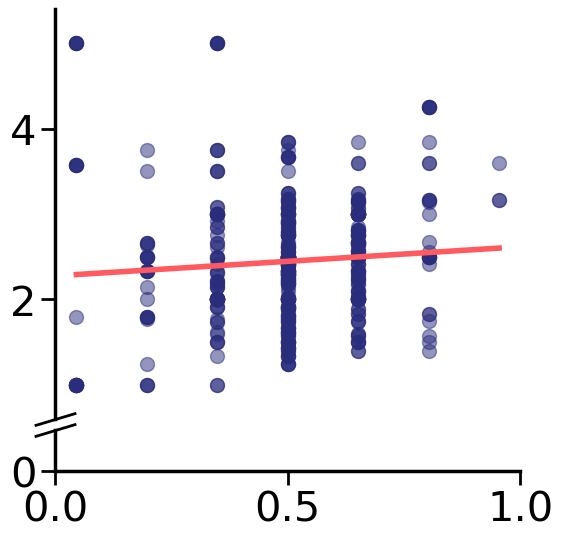

num_leaves
Mean RMSE: 0.7426 $\pm$ 0.06630
n=495
Feature 0 corr=0.121, $p$=0.00703


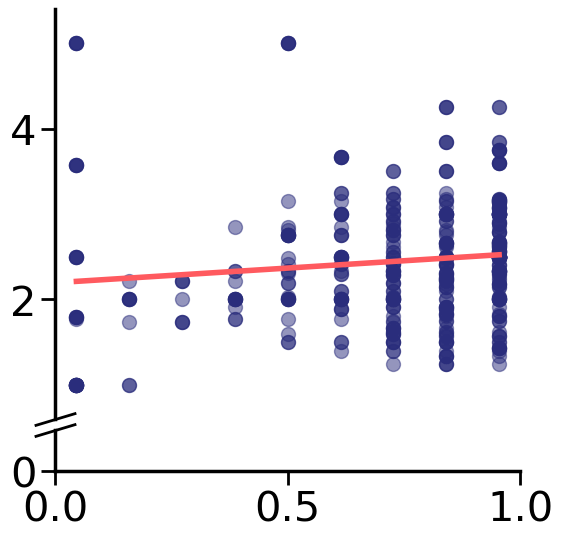

all flow tree
Mean RMSE: 0.7643 $\pm$ 0.07774
Feature 3 corr=0.121, $p$=0.00703
1.32  num_leaves regression line
Feature 0 corr=0.109, $p$=0.01508
1.09 num_nodes regression line
Feature 4 corr=0.046, $p$=0.31108
0.77 avg_branching_factor regression line
embeddings
Mean RMSE: 0.7533 $\pm$ 0.06460
n=495
Feature 0 corr=0.058, $p$=0.19887


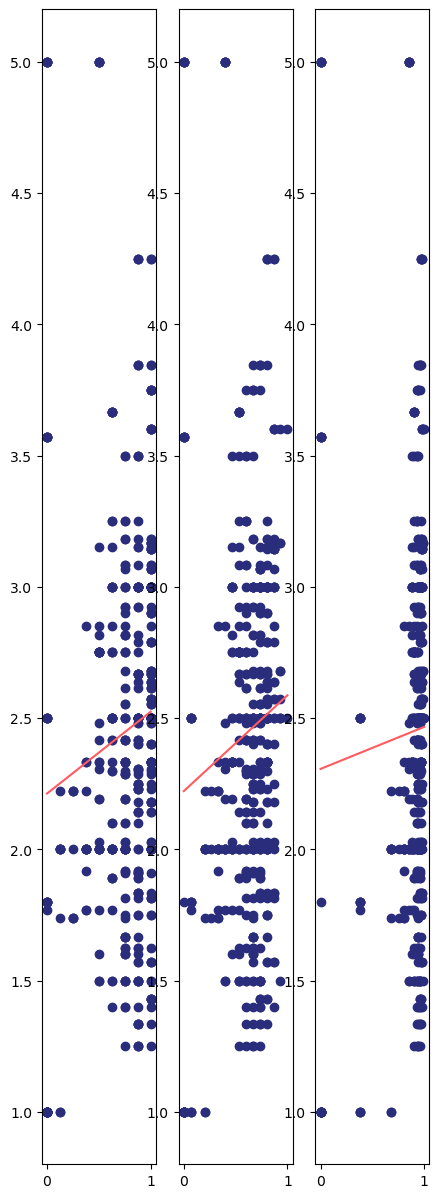

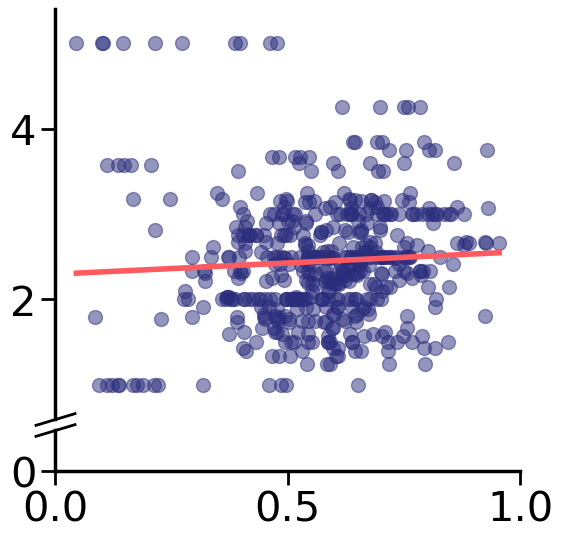

Mean RMSE: 0.7502 $\pm$ 0.06707
n=495
Feature 0 corr=-0.057, $p$=0.20494


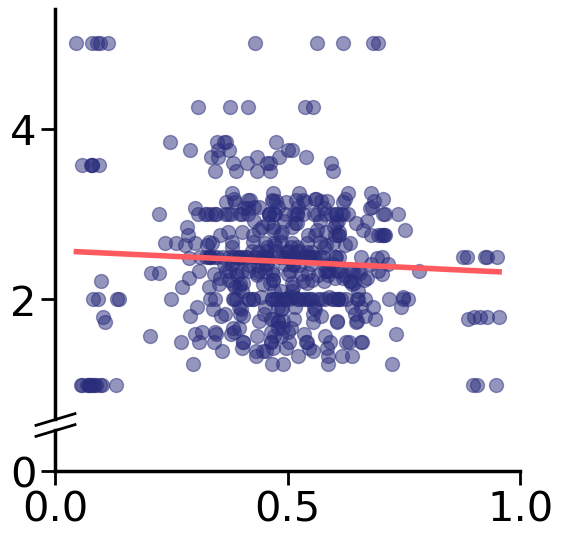

In [111]:
# NOW WITH RATINGS
rat_nans = np.isnan(ratings)
ratings_nona = ratings[~rat_nans]
ft_feats = flow_tree_features[~rat_nans,:]

# norm features
normed_flow_tree_features = np.ones_like(ft_feats)
for i in range(ft_feats.shape[1]):
    normed = ft_feats[:,i]
    min_val, max_val = normed.min(), normed.max()
    normed = (normed - min_val) / (max_val - min_val)

    normed_flow_tree_features[:,i] = normed
    
    
# Flow Tree
print("num_nodes")
run_evaluate_regression(normed_flow_tree_features[:,0].reshape(-1, 1), ratings_nona, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""], y_axis=True)

print("depth")
run_evaluate_regression(normed_flow_tree_features[:,1].reshape(-1, 1), ratings_nona, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("avg_branching_factor")
run_evaluate_regression(normed_flow_tree_features[:,-2].reshape(-1, 1), ratings_nona, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("backbone_thickness")
run_evaluate_regression(normed_flow_tree_features[:,-1].reshape(-1, 1), ratings_nona, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("diameter")
run_evaluate_regression(normed_flow_tree_features[:,2].reshape(-1, 1), ratings_nona, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("num_leaves")
run_evaluate_regression(normed_flow_tree_features[:,3].reshape(-1, 1), ratings_nona, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("all flow tree")
run_evaluate_regression(normed_flow_tree_features, ratings_nona, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])


print("embeddings")
run_evaluate_regression(reduced_features[~rat_nans,0].reshape(-1, 1), ratings_nona, feature_str="pca1,pca2", axes=["", "", ""])
run_evaluate_regression(reduced_features[~rat_nans,-1].reshape(-1, 1), ratings_nona, feature_str="pca1,pca2", axes=["", "", ""])